In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv(r"D:\energy-ai-assistant\data\energy_consumption.csv")
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,4/1/2025,8.4,4,17.8,No,3.2
1,H00001,4/2/2025,7.9,4,17.3,No,2.8
2,H00001,4/3/2025,9.2,4,18.6,No,3.0
3,H00001,4/4/2025,7.9,4,18.2,No,2.7
4,H00001,4/5/2025,9.6,4,11.9,No,3.2


In [5]:
df_cleaned = df[df["Date"] != "4/8/2025"]

In [6]:
summary = df_cleaned.groupby("Household_ID").agg({
    "Energy_Consumption_kWh": ["sum", "mean"],
    "Peak_Hours_Usage_kWh": ["mean"],
    "Avg_Temperature_C": ["mean"],
    "Household_Size": "first",
    "Has_AC": "first"
})

summary.columns = [
    "total_consumption_7d",   
    "avg_consumption_7d",     
    "avg_peak_usage_7d",
    "avg_temperature_7d",
    "household_size",
    "has_ac"
]

summary = summary.reset_index()
summary["has_ac"] = summary["has_ac"].map({"Yes": 1, "No": 0})
summary.head()

,Household_ID,total_consumption_7d,avg_consumption_7d,avg_peak_usage_7d,avg_temperature_7d,household_size,has_ac
0,H00001,59.6,8.514286,2.985714,16.742857,4,0
1,H00002,87.4,12.485714,4.500000,18.257143,5,0
2,H00003,53.6,7.657143,2.685714,16.828571,3,0
3,H00004,125.8,17.971429,8.085714,16.942857,5,1
4,H00005,92.7,13.242857,4.414286,18.000000,5,0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

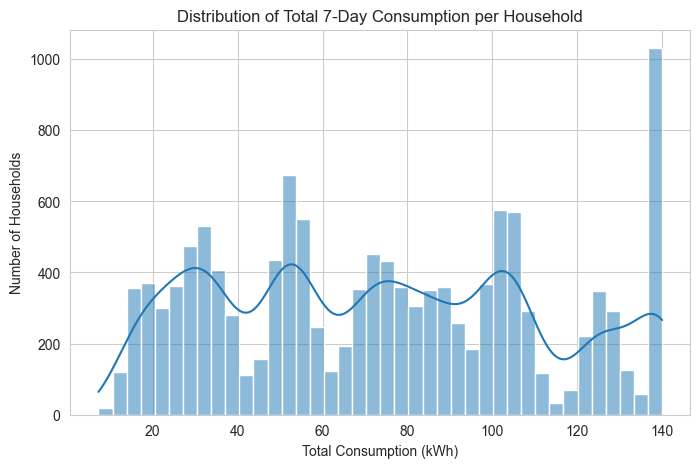

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(summary["total_consumption_7d"], bins=40, kde=True)
plt.title("Distribution of Total 7-Day Consumption per Household")
plt.xlabel("Total Consumption (kWh)")
plt.ylabel("Number of Households")
plt.show()

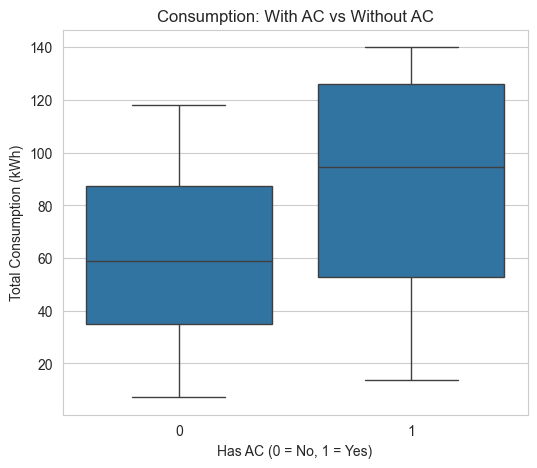

In [9]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=summary, x="has_ac", y="total_consumption_7d")
plt.title("Consumption: With AC vs Without AC")
plt.xlabel("Has AC (0 = No, 1 = Yes)")
plt.ylabel("Total Consumption (kWh)")
plt.show()

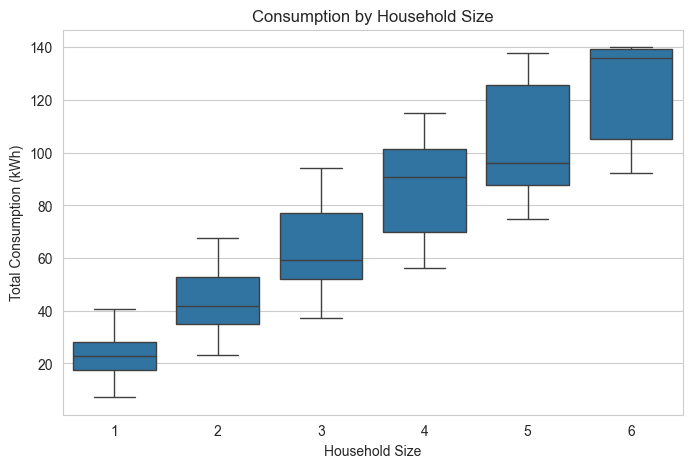

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=summary, x="household_size", y="total_consumption_7d")
plt.title("Consumption by Household Size")
plt.xlabel("Household Size")
plt.ylabel("Total Consumption (kWh)")
plt.show()

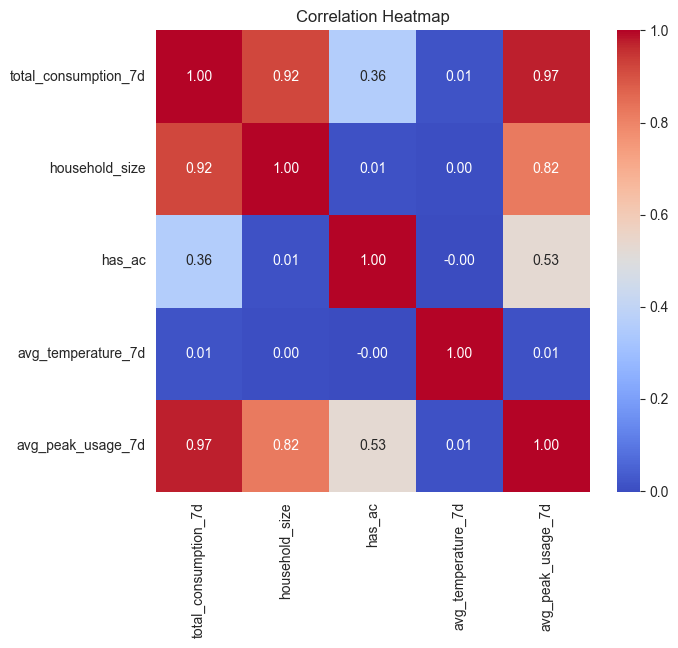

In [11]:
plt.figure(figsize=(7, 6))
correlation_matrix = summary[[
    "total_consumption_7d",
    "household_size",
    "has_ac",
    "avg_temperature_7d",
    "avg_peak_usage_7d"
]].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = summary[[
    "household_size",
    "has_ac",
    "avg_temperature_7d"
    
]]

y = summary["total_consumption_7d"]   

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.3718375162158933
RMSE: 4.327021189827753
R2: 0.9868751909315367


In [15]:
tariff = {
    50: 0.68,
    100: 0.87,
    200: 1.06,
    350: 1.74,
    650: 2.18,
    1000: 2.35,
    float("inf"): 2.89
}


def calculate_bill(kwh):
    bill = 0
    previous_limit = 0

    for limit, price in tariff.items():
        if kwh <= previous_limit:
            break

        consumption = min(kwh, limit) - previous_limit
        bill += consumption * price
        previous_limit = limit

    return bill

In [ ]:

sample_prediction = model.predict(X_test.iloc[[0]])[0]
sample_monthly = sample_prediction * (30 / 7)
sample_bill = calculate_bill(sample_monthly)

print("Predicted weekly consumption:", sample_prediction, "kWh")
print("Projected monthly consumption:", sample_monthly, "kWh")
print("Estimated bill:", sample_bill, "EGP")

Predicted weekly consumption: 123.88451051693409 kWh
Projected monthly consumption: 530.933616501146 kWh
Estimated bill: 838.9352839724984 EGP


In [17]:
joblib.dump(model, r"D:\energy-ai-assistant\app\consumption_model.pkl")

print("تم حفظ الموديل في: app/consumption_model.pkl")

تم حفظ الموديل في: app/consumption_model.pkl
